In [1]:
# Install datasets Library (if not already installed)
# !pip install -U datasets

# Importing Libraries
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Matplotlib is building the font cache; this may take a moment.


README.md: 0.00B [00:00, ?B/s]

c:\Users\eslam\anaconda3\envs\python_course\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eslam\.cache\huggingface\hub\datasets--lukebarousse--data_jobs. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Old caching folder C:\Users\eslam\.cache\huggingface\datasets/lukebarousse___data_jobs/default/0.0.0

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

In [3]:
# Prepare top 10 locations with counts and percentages
df_plot = (
    df_DA_US['job_location']
    .value_counts()
    .head(10)
    .rename_axis('job_location')
    .reset_index(name='count')
)
# Add percentage column
df_plot['percentage'] = 100 * df_plot['count'] / df_plot['count'].sum()

# Show the table for inspection
df_plot

,job_location,count,percentage
0,Anywhere,5106,22.410463
1,"New York, NY",3035,13.320751
2,"Atlanta, GA",2741,12.030372
3,"Chicago, IL",2337,10.257198
4,"Austin, TX",1919,8.422577
5,"Dallas, TX",1862,8.172402
6,"Washington, DC",1592,6.987360
7,"Charlotte, NC",1433,6.289501
8,"Tampa, FL",1431,6.280723
9,"Los Angeles, CA",1328,5.828652


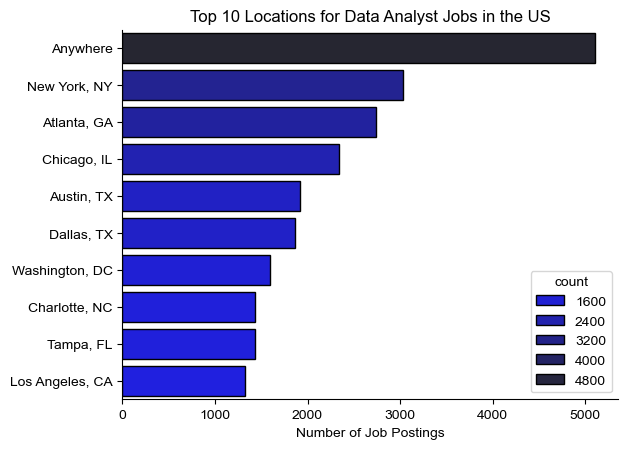

In [4]:
import seaborn as sns
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', orient='h', edgecolor='black')
sns.despine()
sns.set_style('whitegrid')
plt.title('Top 10 Locations for Data Analyst Jobs in the US')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()

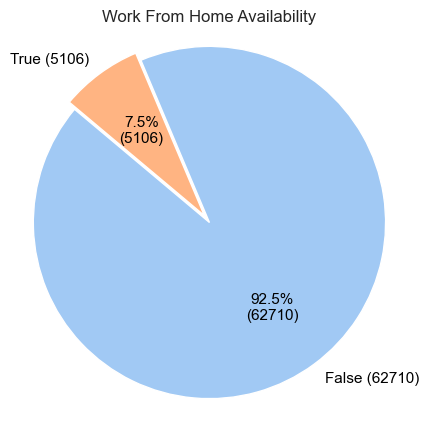

In [5]:
import seaborn as sns
sns.set_style('whitegrid')

# Improved single pie chart for work from home
counts = df_DA_US['job_work_from_home'].value_counts()
fig, ax = plt.subplots(figsize=(5,5))
colors = sns.color_palette('pastel')[:len(counts)]
explode = [0.05 if v == counts.max() else 0 for v in counts.values]
labels = [f"{str(idx)} ({val})" for idx, val in zip(counts.index, counts.values)]

ax.pie(
    counts,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*counts.sum()))})",
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops=dict(edgecolor='white', linewidth=1),
    textprops=dict(color='black', fontsize=11)
)
ax.set_title('Work From Home Availability')
ax.axis('equal')
plt.show()

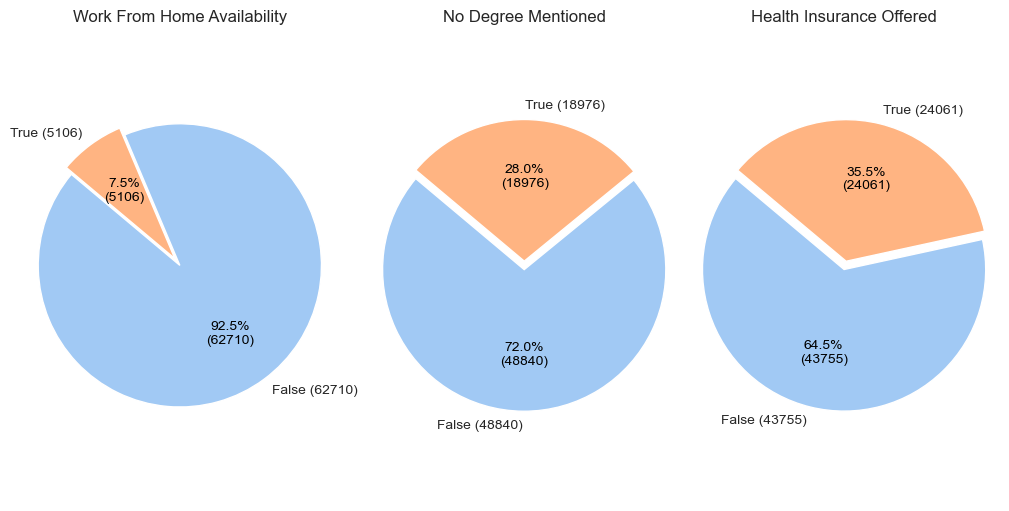

In [6]:
import seaborn as sns
sns.set_style('whitegrid')

cols = [
    ('job_work_from_home','Work From Home Availability'),
    ('job_no_degree_mention', 'No Degree Mentioned'),
    ('job_health_insurance','Health Insurance Offered'),
]

fig, axes = plt.subplots(1, 3, figsize=(10,5), constrained_layout=True)
palette = sns.color_palette('pastel')

def plot_pie(ax, series, title):
    counts = series.value_counts()
    colors = palette[:len(counts)]
    explode = [0.06 if v == counts.max() else 0 for v in counts.values]
    labels = [f"{str(idx)} ({val})" for idx, val in zip(counts.index, counts.values)]

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=labels,
        autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*counts.sum()))})",
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops=dict(edgecolor='white', linewidth=1)
    )
    ax.set_title(title)
    ax.axis('equal')
    for t in autotexts:
        t.set_color('black')
        t.set_fontsize(10)

for ax, (col, title) in zip(axes, cols):
    plot_pie(ax, df_DA_US[col], title)

plt.show()

In [7]:
df_company = df_DA_US['company_name'].value_counts().head(10).to_frame()

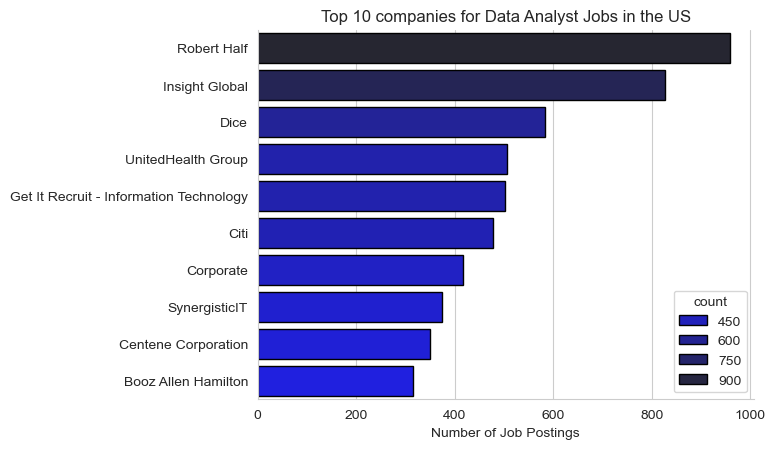

In [8]:
sns.barplot(data=df_company, x='count', y='company_name', hue='count', palette='dark:b_r', orient='h', edgecolor='black')
sns.despine()
sns.set_theme(style= 'ticks')
plt.title('Top 10 companies for Data Analyst Jobs in the US')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()